In [1]:
import pandas as pd 

In [2]:
try:
    hd = pd.read_csv("heart_disease_uci_expanded.csv")
except FileNotFoundError:
    print("Dataset file not found. Check the file path.")
except pd.errors.EmptyDataError:
    print("The CSV file is empty.")
else:
    print("The CSV file loaded successfully.")

The CSV file loaded successfully.


## Setup for Visualizations

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 1. Distribution of Target Variable (`num`)

num
0    2189
1    1375
2     699
3     533
4     204
Name: count, dtype: int64

num
0    43.8
1    27.5
2    14.0
3    10.7
4     4.1
Name: proportion, dtype: float64


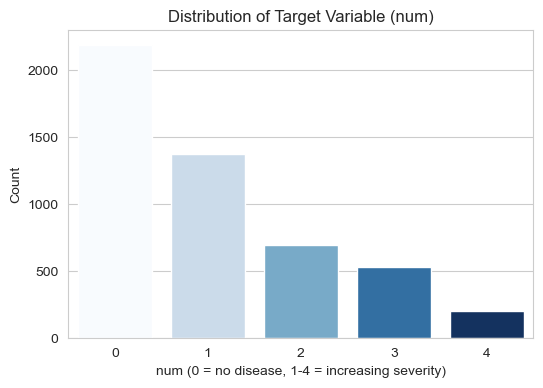

In [4]:
print(hd['num'].value_counts().sort_index())
print()
print((hd['num'].value_counts(normalize=True).sort_index() * 100).round(1))

plt.figure(figsize=(6, 4))
sns.countplot(x='num', data=hd, hue='num', palette='Blues', legend=False)
plt.title("Distribution of Target Variable (num)")
plt.xlabel("num (0 = no disease, 1-4 = increasing severity)")
plt.ylabel("Count")
plt.show()

**Binary breakdown** — `num > 0` collapses the 5-class severity scale into a simple disease / no-disease view, which is often more useful for a quick balance check.

num
1    2811
0    2189
Name: count, dtype: int64

num
1    56.2
0    43.8
Name: proportion, dtype: float64


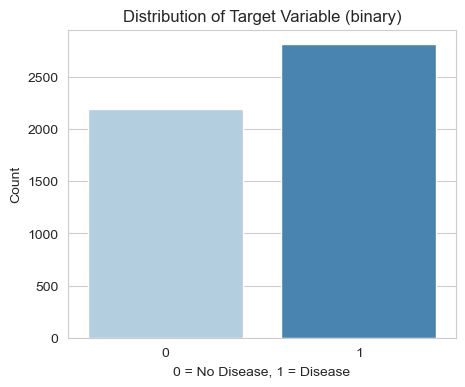

In [5]:
binary_target = hd['num'].apply(lambda x: 1 if x > 0 else 0)

print(binary_target.value_counts())
print()
print((binary_target.value_counts(normalize=True) * 100).round(1))

plt.figure(figsize=(5, 4))
sns.countplot(x=binary_target, hue=binary_target, palette='Blues', legend=False)
plt.title("Distribution of Target Variable (binary)")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.show()

## 2. Distribution of Key Variables

### Numeric Variables \nHistograms with a density curve, showing the shape and spread of each continuous feature.

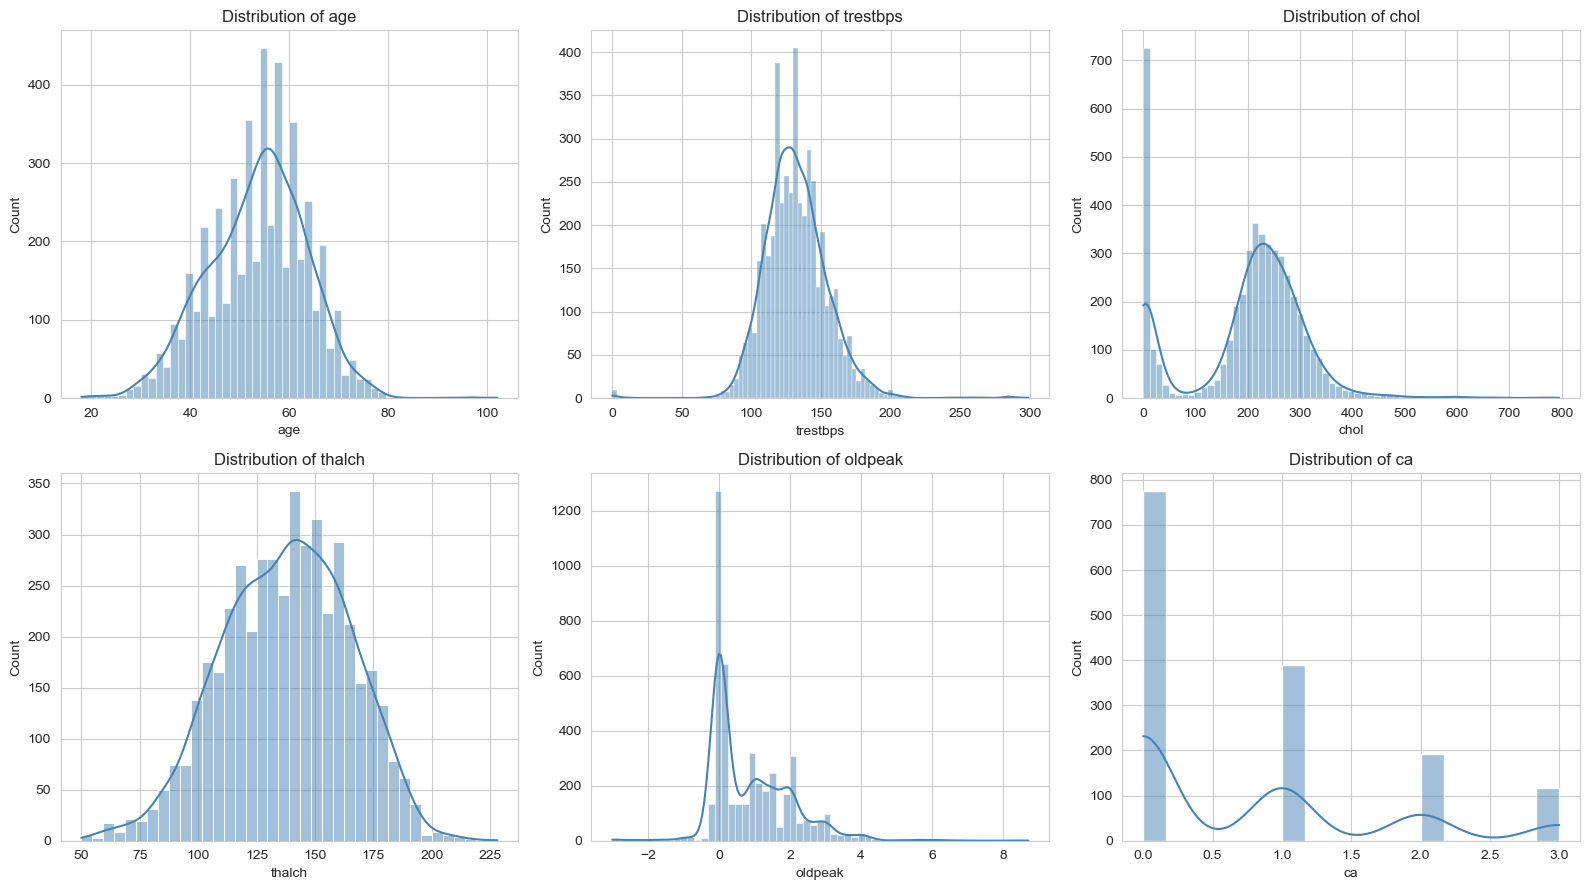

In [6]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(hd[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Categorical Variables \nCount plots showing how many patients fall into each category, including missing values (shown as `NaN` where applicable).

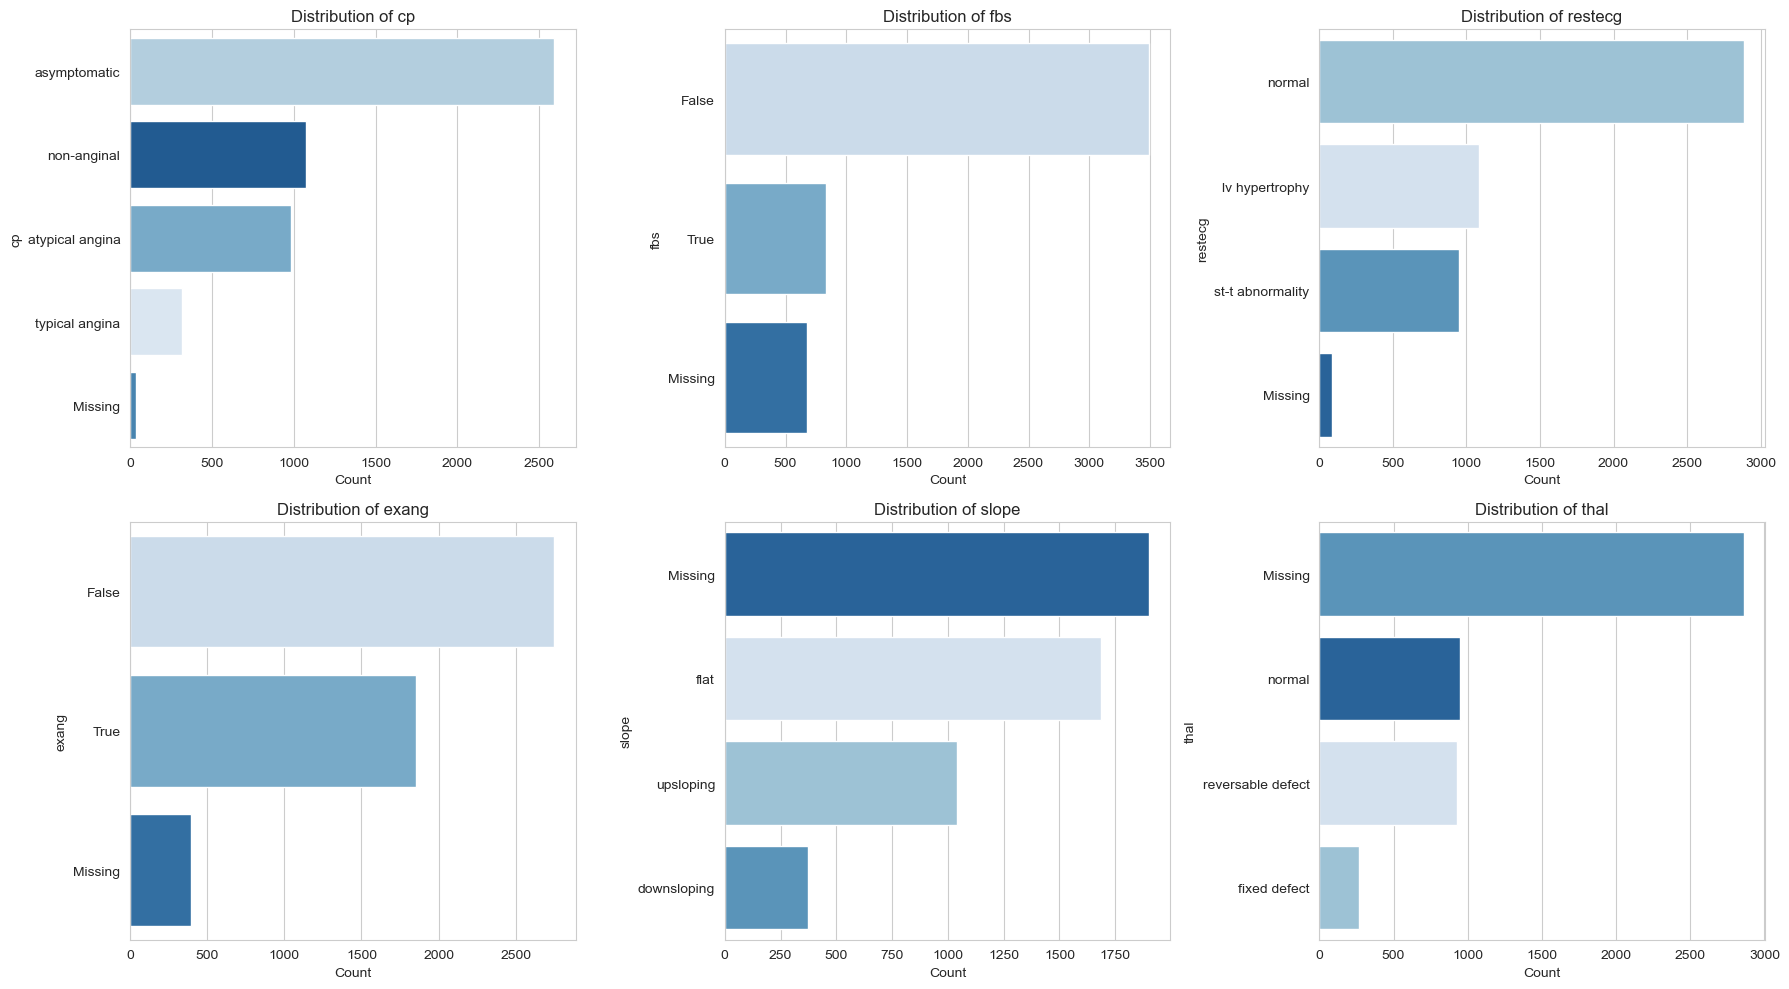

In [7]:
categorical_cols = ['cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# fill NaN with an explicit 'Missing' label for plotting only —
# seaborn/matplotlib can't mix text categories with float NaN on the same axis
plot_df = hd[categorical_cols].fillna('Missing').astype(str)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = plot_df[col].value_counts().index
    sns.countplot(y=col, data=plot_df, order=order, hue=col, palette='Blues', legend=False, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Summary Table — All Key Variables \nQuick reference: missing count, unique values, and either descriptive stats (numeric) or the most frequent category (categorical).

In [8]:
key_vars = ['age', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

summary_rows = []
for col in key_vars:
    row = {
        "Variable": col,
        "Missing": hd[col].isnull().sum(),
        "Missing %": round(hd[col].isnull().mean() * 100, 1),
    }
    if pd.api.types.is_numeric_dtype(hd[col]):
        row["Mean"] = round(hd[col].mean(), 2)
        row["Std"] = round(hd[col].std(), 2)
        row["Min"] = hd[col].min()
        row["Max"] = hd[col].max()
    else:
        row["Most Frequent"] = hd[col].mode().iloc[0] if not hd[col].mode().empty else None
        row["Unique Categories"] = hd[col].nunique()
    summary_rows.append(row)

pd.DataFrame(summary_rows)

,Variable,Missing,Missing %,Mean,Std,Min,Max,Most Frequent,Unique Categories
0,age,27,0.5,53.57,9.87,18.0,102.0,NaN,NaN
1,cp,34,0.7,NaN,NaN,NaN,NaN,asymptomatic,4.0
2,trestbps,438,8.8,131.93,22.58,0.0,299.0,NaN,NaN
3,chol,241,4.8,199.63,112.75,0.0,795.0,NaN,NaN
4,fbs,674,13.5,NaN,NaN,NaN,NaN,False,2.0
5,restecg,84,1.7,NaN,NaN,NaN,NaN,normal,3.0
6,thalch,387,7.7,137.62,27.17,50.0,228.0,NaN,NaN
7,exang,397,7.9,NaN,NaN,NaN,NaN,False,2.0
8,oldpeak,457,9.1,0.88,1.15,-3.0,8.7,NaN,NaN
9,slope,1901,38.0,NaN,NaN,NaN,NaN,flat,3.0
